In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


In [4]:
file_2023 = "DATA TABLE-2023- SALE 50.xlsx"
file_2024 = "DATA TABLE-2024- SALE  51.xlsx"
file_2025 = "DATA TABLE-2025- SALE  46- up to November.xlsx"  # new file

df_2023 = pd.read_excel(file_2023, sheet_name="DATA")
df_2024 = pd.read_excel(file_2024, sheet_name="DATA")
df_2025 = pd.read_excel(file_2025, sheet_name="DATA")

df_all = pd.concat([df_2023, df_2024, df_2025], ignore_index=True)


In [5]:
print("df_2023 shape:", df_2023.shape)
print("df_2024 shape:", df_2024.shape)
print("Combined shape:", df_all.shape)

df_2023.head(5)

df_2023 shape: (491606, 26)
df_2024 shape: (523263, 33)
Combined shape: (1503888, 33)


,YEAR,MONTH,BROKER,LOT NO,SALE NO,INV NO,MF,REF,MARK,SALE TYPE,...,BUYER CODE,BUYER NAME,CHEST,CATEGORY,MF/BF,MFREF,FACTORY,ELE1,ELE2,GROUP
0,2023,JAN,AS,1,1,414,MFH,344,GALEWELA SUPER,PUBLIC AUCTION,...,J2,A.F. JONES (EXPORTS) CE,20.0,EX-ESTATE,MF,MF0344,MATALE WEST,Medium,WM,0
1,2023,JAN,AS,2,1,415,MFH,344,GALEWELA SUPER,PUBLIC AUCTION,...,J2,A.F. JONES (EXPORTS) CE,20.0,EX-ESTATE,MF,MF0344,MATALE WEST,Medium,WM,0
2,2023,JAN,AS,4,1,66,MF,62,KELANEIYA & BRAEMAR,PUBLIC AUCTION,...,S080,SUNSHINE CONSUMER LANKA,10.0,EX-ESTATE,MF,MF0062,KELANEIYA,High,WH,0
3,2023,JAN,AS,5,1,248R,MF,1003,SHANNON,PUBLIC AUCTION,...,D332,DILMA CEYLON TEA CO PLC,10.0,EX-ESTATE,MF,MF1003,SHANNON,High,WH,0
4,2023,JAN,AS,7,1,235R,MF,1003,SHANNON,PUBLIC AUCTION,...,U102,UNI WORLD TEAS (PVT) LT,20.0,EX-ESTATE,MF,MF1003,SHANNON,High,WH,0


In [6]:
df_mid = df_all[df_all["ELE1"] == "Medium"].copy()
print("mid elevation rows:", len(df_mid))
df_mid[['YEAR', 'SALE NO', 'GRADE', 'QTY', 'PRICE', 'ELE1']].head()

mid elevation rows: 250027


,YEAR,SALE NO,GRADE,QTY,PRICE,ELE1
0,2023,1,BOPF,1120.0,900.0,Medium
1,2023,1,BOPF,1120.0,920.0,Medium
60,2023,1,BOPF,1097.0,940.0,Medium
61,2023,1,BOPF,1097.0,940.0,Medium
66,2023,1,OPA,880.0,1500.0,Medium


In [7]:
def make_weekly_mid(df_mid: pd.DataFrame) -> pd.DataFrame:
    df_tmp = df_mid.copy()
    df_tmp["PRICE"] = pd.to_numeric(df_tmp["PRICE"], errors="coerce")
    df_tmp["QTY"]   = pd.to_numeric(df_tmp["QTY"], errors="coerce")

    df_tmp["value"] = df_tmp["PRICE"] * df_tmp["QTY"]

    grouped = (
        df_tmp
        .groupby(["YEAR", "SALE NO", "GRADE"], as_index=False)
        .agg(
            total_qty   = ("QTY", "sum"),
            total_value = ("value", "sum"),
        )
    )

    grouped["avg_price"] = grouped["total_value"] / grouped["total_qty"]

    grouped["week_date"] = (
        pd.to_datetime(grouped["YEAR"].astype(str), format="%Y")
        + pd.to_timedelta((grouped["SALE NO"] - 1) * 7, unit="D")
    )

    return grouped[["YEAR", "SALE NO", "GRADE", "total_qty", "avg_price", "week_date"]]

weekly_mid = make_weekly_mid(df_mid)

print("Weekly mid-elevation table head:")
display(weekly_mid.head())

print("\nDistinct grades in mid elevation:", weekly_mid["GRADE"].nunique())
print("Sample grades:", sorted(weekly_mid["GRADE"].unique())[:20])


Weekly mid-elevation table head:


,YEAR,SALE NO,GRADE,total_qty,avg_price,week_date
0,2023,1,BM,58750.0,803.281702,2023-01-01
1,2023,1,BOP,17054.0,1431.499941,2023-01-01
2,2023,1,BOP1,11104.0,1832.772875,2023-01-01
3,2023,1,BOP1A,36388.0,922.696768,2023-01-01
4,2023,1,BOPA,23324.0,1012.187018,2023-01-01



Distinct grades in mid elevation: 272
Sample grades: ['BLACK FF', 'BM', 'BOP', 'BOP1', 'BOP1A', 'BOPA', 'BOPF', 'BOPFSP', 'BOPSP', 'BP', 'BP1', 'BPS', 'BT', 'BTFINED1', 'C.S FGS', 'C.S OP', 'C.S.FGS', 'C.S.OP', 'CERLON SAN', 'CEY GT SUP']


In [8]:
import numpy as np
import pandas as pd

def compute_metrics(y_test, y_pred):
    """
    Robust metrics that:
      - align y_test and y_pred
      - ignore any NaNs
    """
    y_test = pd.Series(y_test).astype(float)
    y_pred = pd.Series(y_pred, index=y_test.index).astype(float)

    diff = y_test - y_pred

    mae  = np.nanmean(np.abs(diff))
    rmse = np.sqrt(np.nanmean(diff ** 2))

    y_safe = y_test.clip(lower=1e-3)
    mape = np.nanmean(np.abs(diff / y_safe)) * 100

    return float(mae), float(rmse), float(mape)


In [9]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

def train_arima_for_grade_mid(
    weekly_mid: pd.DataFrame,
    grade: str,
    min_points: int = 30,
    test_weeks: int = 52,
):
    # Filter and clean for this grade
    gdf = weekly_mid[weekly_mid["GRADE"] == grade].copy()
    gdf = gdf.sort_values("week_date")
    gdf = gdf.dropna(subset=["avg_price"])

    if len(gdf) < min_points:
        print(f"⚠️ Grade {grade}: only {len(gdf)} valid points after dropping NaNs, skipping.")
        return None

    # Build time series y
    y = pd.Series(gdf["avg_price"].values, index=gdf["week_date"]).astype(float)

    #Train / test split
    if len(y) <= test_weeks + 10:
        split_idx = int(len(y) * 0.8)
    else:
        split_idx = len(y) - test_weeks

    y_train = y.iloc[:split_idx]
    y_test  = y.iloc[split_idx:]

    if len(y_test) == 0:
        print(f"⚠️ Grade {grade}: empty test set, skipping.")
        return None

    #Fit ARIMA on TRAIN
    model_train = ARIMA(y_train, order=(1, 1, 1))
    res_train   = model_train.fit()

    # Forecast TEST horizon
    y_pred_raw = res_train.forecast(steps=len(y_test))
    y_pred     = pd.Series(np.asarray(y_pred_raw, dtype=float), index=y_test.index)

    # Manual metrics (ignore NaNs if any)
    diff = y_test - y_pred

    mae  = float(np.nanmean(np.abs(diff)))
    rmse = float(np.sqrt(np.nanmean(diff**2)))
    mape = float(np.nanmean(np.abs(diff / y_test.clip(lower=1e-3))) * 100)

    #Refit on FULL series for future forecasts
    model_full = ARIMA(y, order=(1, 1, 1)).fit()

    return {
        "grade": grade,
        "n_points": len(y),
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "model": model_full,           # full model for future forecasts
        "y_price": y,                  # full history
        "y_test_price": y_test,        # test actual
        "y_pred_test_price": y_pred,   # test predicted
    }


In [10]:
results_mid_arima = []
models_mid_arima  = {}

for g in sorted(weekly_mid["GRADE"].unique()):
    print(f"→ Grade {g}")
    info = train_arima_for_grade_mid(weekly_mid, g)

    if info is None:
        continue

    results_mid_arima.append({
        "elevation": "Medium",
        "grade": info["grade"],
        "n_points": info["n_points"],
        "MAE": info["mae"],
        "RMSE": info["rmse"],
        "MAPE_%": info["mape"],
    })
    models_mid_arima[g] = info

metrics_mid_arima = pd.DataFrame(results_mid_arima).sort_values("MAPE_%")
display(metrics_mid_arima.head(20))


→ Grade BLACK FF
⚠️ Grade BLACK FF: only 3 valid points after dropping NaNs, skipping.
→ Grade BM


C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.

→ Grade BOP
→ Grade BOP1
→ Grade BOP1A
→ Grade BOPA


C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.

→ Grade BOPF
→ Grade BOPFSP
→ Grade BOPSP
→ Grade BP


...

→ Grade SECHAFGS
⚠️ Grade SECHAFGS: only 1 valid points after dropping NaNs, skipping.
→ Grade SILV GREEN
⚠️ Grade SILV GREEN: only 2 valid points after dropping NaNs, skipping.
→ Grade SILVER TIP
→ Grade SILVERTIPS
→ Grade SIVER CURL
⚠️ Grade SIVER CURL: only 7 valid points after dropping NaNs, skipping.
→ Grade SP-HYSON
⚠️ Grade SP-HYSON: only 2 valid points after dropping NaNs, skipping.
→ Grade SPECIAL HY
⚠️ Grade SPECIAL HY: only 2 valid points after dropping NaNs, skipping.
→ Grade SPECIAL TE
⚠️ Grade SPECIAL TE: only 1 valid points after dropping NaNs, skipping.
→ Grade SWEET16
⚠️ Grade SWEET16: only 2 valid points after dropping NaNs, skipping.
→ Grade TEA BLOSSO
⚠️ Grade TEA BLOSSO: only 7 valid points after dropping NaNs, skipping.
→ Grade TEA FLOWER
⚠️ Grade TEA FLOWER: only 1 valid points after dropping NaNs, skipping.
→ Grade TEAFLOWER
⚠️ Grade TEAFLOWER: only 2 valid points after dropping NaNs, skipping.
→ Grade WHITE TEA
⚠️ Grade WHITE TEA: only 13 valid points after dro

C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.

→ Grade YH
→ Grade YH2
⚠️ Grade YH2: only 1 valid points after dropping NaNs, skipping.


C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g

,elevation,grade,n_points,MAE,RMSE,MAPE_%
58,Medium,WTBL,47,15.000922,27.384390,1.500102
44,Medium,GTSPHYSON,46,21.967427,31.479796,1.565690
14,Medium,CGT SP HY,48,26.306224,38.068498,1.703071
40,Medium,GTGPSP,54,41.504381,61.352638,2.289572
12,Medium,C.S.FGS,45,29.166286,35.968886,2.539785
42,Medium,GTSENFGS,87,31.099071,45.400070,2.693848
33,Medium,GTF,44,29.759534,34.278479,2.736420
16,Medium,CGTGP1,32,51.012992,88.502104,2.823390
43,Medium,GTSPHY,72,41.008243,54.708083,2.850320
54,Medium,PF1,147,28.751848,35.696451,3.105415


In [11]:
metrics_mid_arima.to_csv("mid_elevation_arima_metrics.csv", index=False)


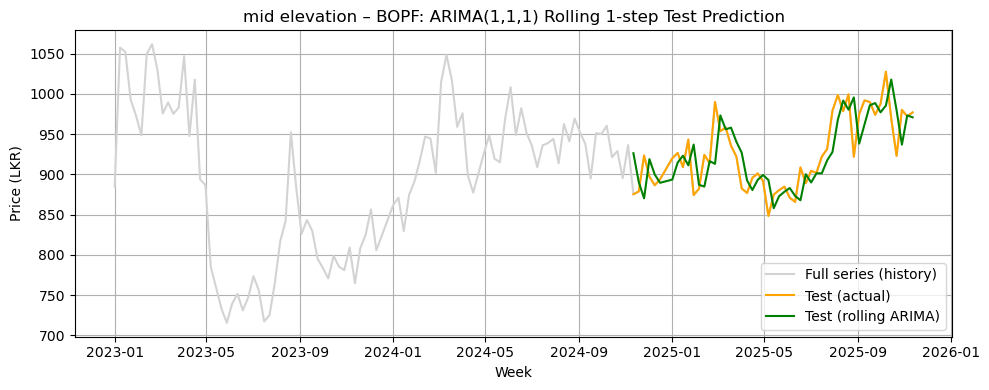

Rolling 1-step: MAE=24.20, RMSE=31.04, MAPE=2.60%


In [12]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def rolling_arima_forecast(y, order=(1,1,1), test_weeks=52):
    """
    y: pd.Series with DateTimeIndex
    Returns:
      y_train, y_test, y_pred_rolling
    """
    if len(y) <= test_weeks + 10:
        split_idx = int(len(y) * 0.8)
    else:
        split_idx = len(y) - test_weeks

    y_train = y.iloc[:split_idx]
    y_test  = y.iloc[split_idx:]

    history = list(y_train.values)
    preds   = []

    for t in range(len(y_test)):
        model = ARIMA(history, order=order)
        res   = model.fit()
        preds.append(res.forecast(steps=1)[0])
        # update with the TRUE value
        history.append(y_test.iloc[t])

    y_pred_roll = pd.Series(preds, index=y_test.index)
    return y_train, y_test, y_pred_roll

# ----- mid – BOPF example -----
gdf_mid = weekly_mid[weekly_mid["GRADE"] == "BOPF"].copy()
gdf_mid = gdf_mid.sort_values("week_date").dropna(subset=["avg_price"])

y_mid = pd.Series(gdf_mid["avg_price"].values,
                  index=gdf_mid["week_date"]).astype(float)

y_train, y_test, y_pred_roll = rolling_arima_forecast(
    y_mid, order=(1,1,1), test_weeks=52
)

# Plot
plt.figure(figsize=(10,4))
plt.plot(y_mid.index, y_mid.values, color="lightgray",
         label="Full series (history)")
plt.plot(y_test.index, y_test.values, label="Test (actual)", color="orange")
plt.plot(y_pred_roll.index, y_pred_roll.values,
         label="Test (rolling ARIMA)", color="green")
plt.title("mid elevation – BOPF: ARIMA(1,1,1) Rolling 1-step Test Prediction")
plt.ylabel("Price (LKR)")
plt.xlabel("Week")
plt.legend()
plt.tight_layout()
plt.show()

# Metrics for rolling forecast
diff = y_test - y_pred_roll
mae  = np.mean(np.abs(diff))
rmse = np.sqrt(np.mean(diff**2))
mape = np.mean(np.abs(diff / y_test.clip(lower=1e-3))) * 100
print(f"Rolling 1-step: MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}%")



In [13]:
def print_metrics_for_mid_arima_grade(grade="BOPF"):
    info = models_mid_arima[grade]
    mae  = info["mae"]
    rmse = info["rmse"]
    mape = info["mape"]

    print(f"ARIMA – mid elevation – {grade}")
    print(f"  MAE  : {mae:.6f} LKR")
    print(f"  RMSE : {rmse:.6f} LKR")
    print(f"  MAPE : {mape:.6f} %")


print_metrics_for_mid_arima_grade("BOPF")

ARIMA – mid elevation – BOPF
  MAE  : 38.495640 LKR
  RMSE : 44.299960 LKR
  MAPE : 4.150881 %


In [14]:
metrics_mid_arima_all = metrics_mid_arima.sort_values("MAPE_%")
display(metrics_mid_arima_all.head(20))


,elevation,grade,n_points,MAE,RMSE,MAPE_%
58,Medium,WTBL,47,15.000922,27.384390,1.500102
44,Medium,GTSPHYSON,46,21.967427,31.479796,1.565690
14,Medium,CGT SP HY,48,26.306224,38.068498,1.703071
40,Medium,GTGPSP,54,41.504381,61.352638,2.289572
12,Medium,C.S.FGS,45,29.166286,35.968886,2.539785
42,Medium,GTSENFGS,87,31.099071,45.400070,2.693848
33,Medium,GTF,44,29.759534,34.278479,2.736420
16,Medium,CGTGP1,32,51.012992,88.502104,2.823390
43,Medium,GTSPHY,72,41.008243,54.708083,2.850320
54,Medium,PF1,147,28.751848,35.696451,3.105415


In [15]:
future_rows_arima = []

N_FUTURE_WEEKS = 52  

for g, info in models_mid_arima.items():
    model = info["model"]          
    y_price_full = info["y_price"]

    last_date = y_price_full.index[-1]

    # future weekly index
    future_index = pd.date_range(
        start=last_date + pd.Timedelta(days=7),
        periods=N_FUTURE_WEEKS,
        freq="7D"
    )

    # ARIMA forecast
    future_vals = model.forecast(steps=N_FUTURE_WEEKS)
    future_series = pd.Series(np.asarray(future_vals, float), index=future_index)

    tmp = pd.DataFrame({
        "elevation": "Medium",
        "grade": g,
        "date": future_series.index,
        "predicted_price": future_series.values,
    })
    future_rows_arima.append(tmp)

future_mid_arima_df = pd.concat(future_rows_arima, ignore_index=True)


C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Nimesh Tharaka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_pre

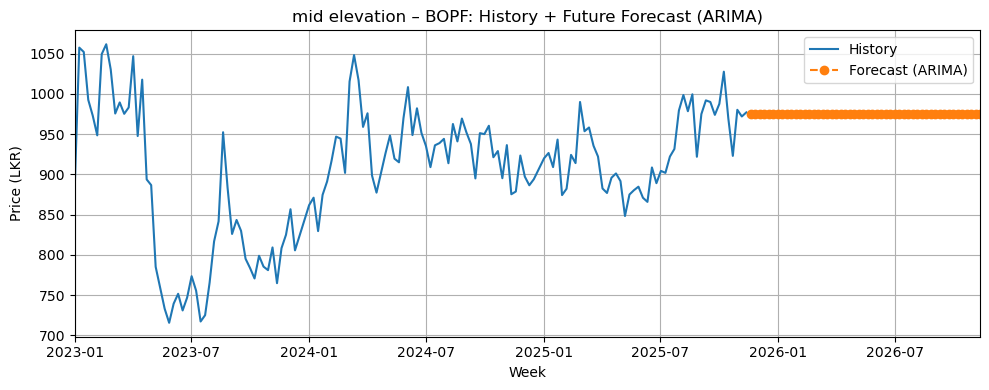

In [16]:
grade_for_demo = "BOPF"

hist_mid = models_mid_arima[grade_for_demo]["y_price"]
future_grade = future_mid_arima_df[future_mid_arima_df["grade"] == grade_for_demo]

plt.figure(figsize=(10, 4))
plt.plot(hist_mid.index, hist_mid.values, label="History")

plt.plot(
    future_grade["date"],
    future_grade["predicted_price"],
    marker="o",
    linestyle="--",
    label="Forecast (ARIMA)",
)

plt.xlim(hist_mid.index.min(), future_grade["date"].max())

plt.title(f"mid elevation – {grade_for_demo}: History + Future Forecast (ARIMA)")
plt.ylabel("Price (LKR)")
plt.xlabel("Week")
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
grade = "BOPF"
info = models_mid_arima[grade]

y_test = info["y_test_price"]
y_pred = info["y_pred_test_price"]

print("len(y_test):", len(y_test))
print("len(y_pred):", len(y_pred))

cmp = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})
print(cmp.head(10))

print("\nDifferences:")
print((cmp["y_test"] - cmp["y_pred"]).abs().describe())


len(y_test): 52
len(y_pred): 52
                y_test      y_pred
week_date                         
2024-11-11  875.461428  926.424218
2024-11-18  878.834512  933.090015
2024-11-25  923.542271  928.667825
2024-12-02  897.328382  931.601572
2024-12-09  886.603536  929.655281
2024-12-16  894.099161  930.946480
2025-01-01  920.151342  930.089879
2025-01-08  926.709930  930.658161
2025-01-15  909.182191  930.281154
2025-01-22  943.347038  930.531266

Differences:
count    52.000000
mean     38.495640
std      22.135833
min       1.267011
25%      21.543614
50%      42.341662
75%      53.609100
max      97.263245
dtype: float64


In [45]:
import statsmodels.api as sm

def diagnose_arima_in_sample(models_dict, grade: str, elevation_label: str = "Medium"):
    """
    In-sample residual diagnostics for ARIMA model of a given grade.
    Uses the full-series model stored in models_*_arima[grade]["model"].
    """
    if grade not in models_dict:
        raise KeyError(f"Grade {grade} not found. Available: {list(models_dict.keys())}")

    info = models_dict[grade]
    model_full = info["model"]      
    resid = pd.Series(model_full.resid)

    print(f"=== In-sample residual diagnostics – {elevation_label} – {grade} – ARIMA ===\n")

    print("Residual summary:")
    print(resid.describe())
    print("\nMean residual (should be close to 0):", resid.mean())


    resid_clean = resid.dropna()
    lb = sm.stats.acorr_ljungbox(resid_clean, lags=[10, 20, 30], return_df=True)
    print("\nLjung–Box test for residual autocorrelation:")
    print(lb)

    fig, axes = plt.subplots(2, 2, figsize=(10, 6))

    axes[0, 0].plot(resid.index, resid.values)
    axes[0, 0].axhline(0, color='black', linewidth=1)
    axes[0, 0].set_title("Residuals over time")
    axes[0, 0].set_xlabel("Week")
    axes[0, 0].set_ylabel("Residual")

    axes[0, 1].hist(resid.values, bins=20)
    axes[0, 1].set_title("Residual histogram")

    sm.graphics.tsa.plot_acf(resid_clean, ax=axes[1, 0], lags=30)
    axes[1, 0].set_title("ACF of residuals")

    sm.qqplot(resid_clean, line='s', ax=axes[1, 1])
    axes[1, 1].set_title("QQ-plot of residuals")

    plt.tight_layout()
    plt.show()

    return lb, resid

In [54]:
def full_arima_diagnostics_for_grade(models_dict, grade: str, elevation_label: str = "High"):
    print("\n" + "="*80)
    print(f"ARIMA diagnostics for {elevation_label} – {grade}")
    print("="*80 + "\n")

    lb_df, resid_full = diagnose_arima_in_sample(models_dict, grade, elevation_label)
    resid_test = diagnose_arima_test_residuals(models_dict, grade, elevation_label)

    return lb_df, resid_full, resid_test



ARIMA diagnostics for Mid – BOPF

=== In-sample residual diagnostics – Mid – BOPF – ARIMA ===

Residual summary:
count    147.000000
mean       6.838869
std       83.622054
min     -114.844509
25%      -21.647161
50%        2.855081
75%       26.823426
max      885.147347
dtype: float64

Mean residual (should be close to 0): 6.838869395064156

Ljung–Box test for residual autocorrelation:
      lb_stat  lb_pvalue
10   6.058785   0.810300
20  12.509558   0.897422
30  13.429159   0.996038


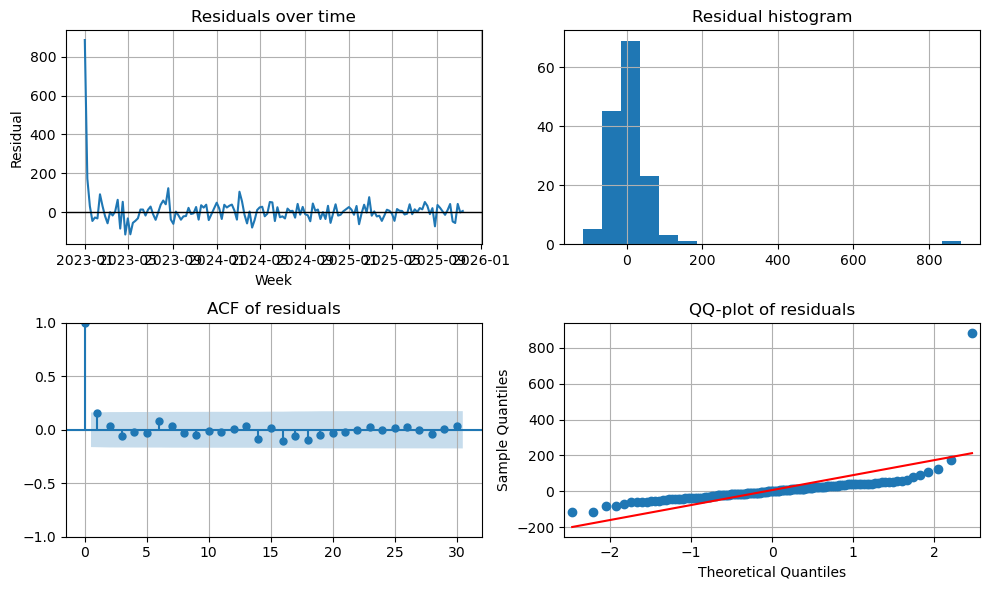

In [55]:
lb_mid_bopf, resid_mid_bopf, test_resid_mid_bopf = full_arima_diagnostics_for_grade(
    models_mid_arima,
    grade="BOPF",
    elevation_label="Mid"
)



Residuals over time
Shows how the model errors change week by week.
For Low–BOPF, there is one big spike at the beginning (an outlier week), but afterwards the residuals are small and fluctuate around zero → the model fits most weeks well.#

Residual histogram
Shows the distribution of errors.
Most residuals are close to zero, with one bar far to the right from the big early outlier. Apart from that, the errors are centred near zero.

ACF of residuals-
Checks whether residuals are still correlated with previous weeks.
All bars (except lag 0) are inside the blue band, and the Ljung–Box p-values are > 0.9, so there is no significant autocorrelation → the ARIMA model has captured the time pattern.

QQ-plot of residuals
Compares residuals to a normal distribution.
Points follow the straight line in the middle and deviate in the tails because of the outlier. This means residuals are roughly normal with some heavy tails due to a few extreme weeks.

In [57]:
import matplotlib.pyplot as plt

def plot_train_test_split(weekly_df, elevation_label: str, grade: str = "BOPF", n_test: int = 52):
    """
    Plot actual weekly price with Train vs Test split.

    weekly_df      : DataFrame with columns ["ELEVATION", "GRADE", "week_date", "avg_price"]
    elevation_label: just for title ("Low", "Medium", "High")
    grade          : tea grade, e.g. "BOPF"
    n_test         : number of last weeks used as TEST (e.g. 52)
    """

    gdf = weekly_df[weekly_df["GRADE"] == grade].copy()
    gdf = gdf.sort_values("week_date")

    if gdf.empty:
        print(f"No data found for {elevation_label} – {grade}")
        return

    y = gdf.set_index("week_date")["avg_price"].astype(float)

    if len(y) <= n_test:
        print(f"Not enough points for {elevation_label} – {grade}. Length={len(y)}, n_test={n_test}")
        return

    split_idx = len(y) - n_test
    y_train = y.iloc[:split_idx]
    y_test  = y.iloc[split_idx:]

    print(f"=== {elevation_label} – {grade} ===")
    print(f"Total points: {len(y)}")
    print(f"Train points: {len(y_train)}  ({y_train.index[0].date()} → {y_train.index[-1].date()})")
    print(f"Test points : {len(y_test)}   ({y_test.index[0].date()} → {y_test.index[-1].date()})")

    plt.figure(figsize=(10, 4))
    plt.plot(y.index, y.values, color="lightgray", label="Full series (actual)")

    plt.plot(y_train.index, y_train.values, label="Train (actual)", color="blue")
    plt.plot(y_test.index,  y_test.values,  label="Test (actual)",  color="orange")

    split_date = y_test.index[0]
    plt.axvline(split_date, color="red", linestyle="--", label=f"Split ({split_date.date()})")

    plt.title(f"{elevation_label} – {grade}: Weekly price (Train vs Test)")
    plt.xlabel("Week")
    plt.ylabel("Average price (LKR)")
    plt.legend()
    plt.tight_layout()
    plt.show()


=== Medium – BOPF ===
Total points: 147
Train points: 95  (2023-01-01 → 2024-11-04)
Test points : 52   (2024-11-11 → 2025-11-12)


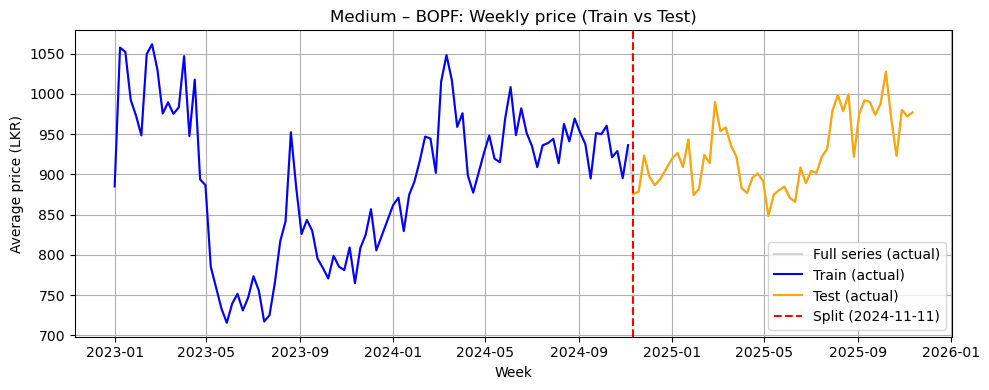

In [58]:
plot_train_test_split(weekly_mid, "Medium", "BOPF", n_test=52)


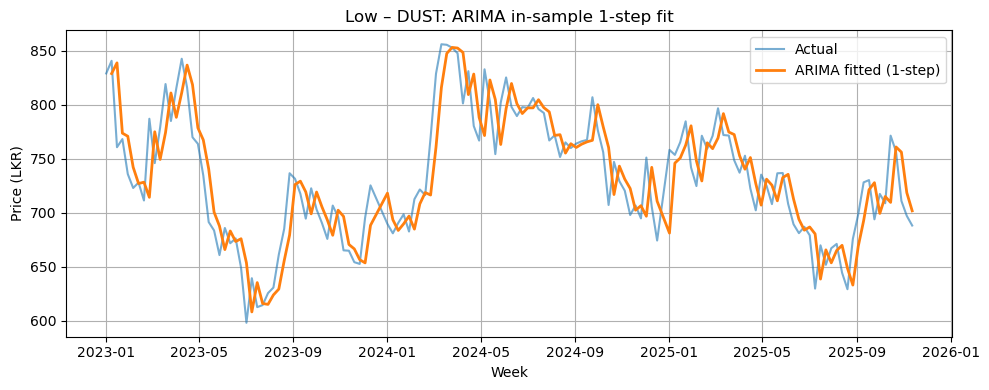

In [59]:
grade = "DUST"
info = models_mid_arima[grade]

model_full = info["model"]
y = info["y_price"]  

fitted = model_full.predict(start=y.index[1], end=y.index[-1], dynamic=False)

plt.figure(figsize=(10,4))
plt.plot(y.index, y.values, label="Actual", alpha=0.6)
plt.plot(fitted.index, fitted.values, label="ARIMA fitted (1-step)", linewidth=2)
plt.title("Low – DUST: ARIMA in-sample 1-step fit")
plt.xlabel("Week")
plt.ylabel("Price (LKR)")
plt.legend()
plt.tight_layout()
plt.show()


In [60]:
import pickle

with open("arima_mid_grade_model.pkl", "wb") as f:
    pickle.dump(models_mid_arima[grade_for_demo]["model"], f)

